In [5]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from base.read_matrix import MatrixDataReader
from base.common import *
from base.impedance_analysis import *

import numpy as np
import matplotlib.pyplot as plt

fsave_set_save(False)
fsave_set_dpi(300)
fsave_set_pad_inches(0.2)
%config InlineBackend.figure_format='svg'

In [6]:
md = MatrixDataReader(['../../run/EC.txt'])
md.read_matrices()

File: ../../run/EC.txt
Rows: 15
Cols: 1107000
Size: 348705000 bytes
Time: 1.61 seconds



In [7]:
# 根据周期更改开始行数
# start_idx = 1845000

time = md.data[0][0]# [start_idx:]
Vccp = md.data[0][1]# [start_idx:]
cap = md.data[0][2]# [start_idx:]
charge = md.data[0][3]# [start_idx:]
Qm1 = md.data[0][4]# [start_idx:]
Qm2 = md.data[0][5]# [start_idx:]
Im2 = md.data[0][6]# [start_idx:]
Qei = md.data[0][7]# [start_idx:]
Istray = md.data[0][8]# [start_idx:]
Qe = md.data[0][9]# [start_idx:]
Vs = md.data[0][10]# [start_idx:]
Iei = md.data[0][11]# [start_idx:]
Vei = md.data[0][12]# [start_idx:]
Iconv = md.data[0][13]# [start_idx:]

In [8]:
print (len(Qm1))
Uload = (Qm1 - Qm2) / (1.5e-10)
Iload = (Vs - Uload) / 50
Iccp = Im2 - Istray

# --- 新增的导出代码 ---
# 将 Uload 和 Iload 拼接到一起，作为两列
data_to_export = np.column_stack((time, Uload, Iload))

# 导出为 UI_0-3000.txt，使用制表符 '\t' 分隔，并加上表头（可选）
print("正在导出到 UI_0-3000.txt ...")
np.savetxt('UI_0-3000.txt', data_to_export, delimiter='\t', header='time\tUload\tIload', comments='')
print("导出完成！")

1107000
正在导出到 UI_0-3000.txt ...
导出完成！


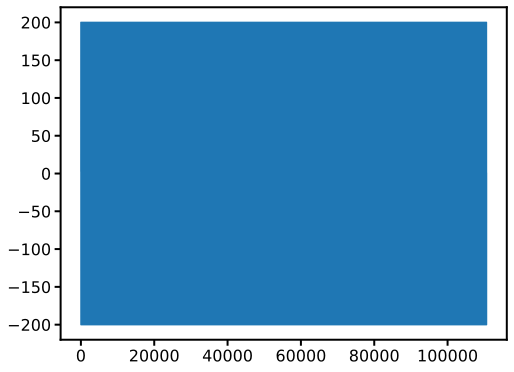

In [9]:
font, size = curvestyle()
plt.plot(time/1e-9, Vs)
fs('./Us')

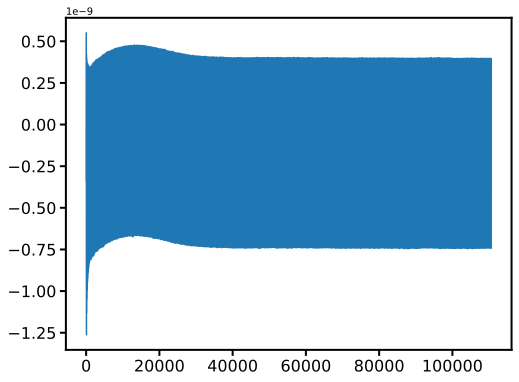

In [10]:
font, size = curvestyle()
plt.plot(time/1e-9, charge)
fs('./charge')

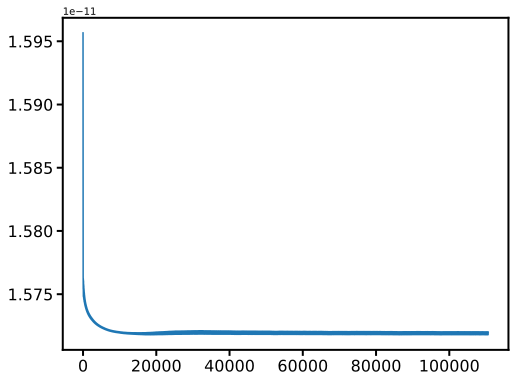

In [11]:
font, size = curvestyle()
plt.plot(time/1e-9, cap)
fs('./cap')

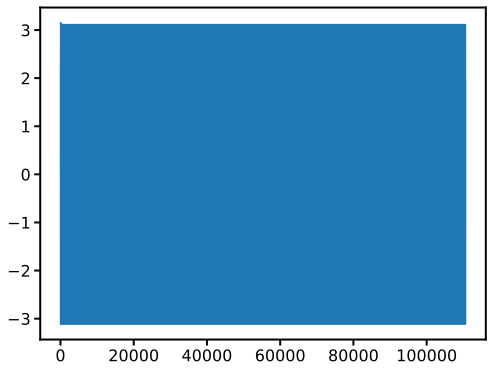

In [12]:
font, size = curvestyle()
plt.plot(time/1e-9, Iload)
fs('./Iload')

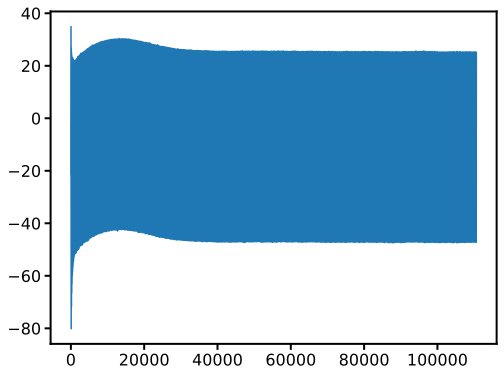

In [13]:
font, size = curvestyle()
plt.plot(time/1e-9, Vccp)
fs('./Uccp')

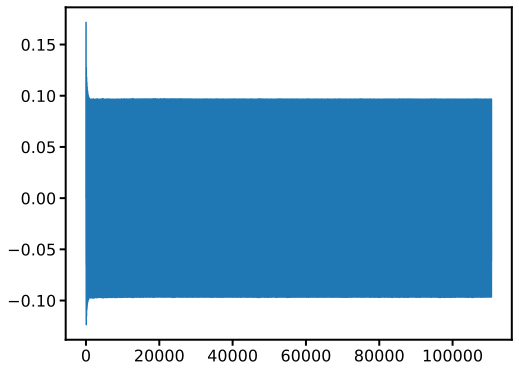

In [14]:
font, size = curvestyle()
plt.plot(time/1e-9, Iccp)
fs('./Iccp')

In [15]:
# dt = time[1] - time[0]
# print(dt)
# f = 27.12e6
# istart = 1500000
# iend = istart + int(500 / 27.12e6 / dt + 0.5)
# istart, iend

In [16]:
# zl = get_equivalent_impedance(Uload[istart:iend], Iload[istart:iend], dt, f)
# zl

In [17]:
# gamma = (zl - 50) / (zl + 50)
# gamma

In [18]:
# np.abs(gamma)

In [19]:
# Zccp = get_equivalent_impedance(Vccp[istart:iend], Iccp[istart:iend], dt, f)
# Zccp

In [20]:
# Rccp = Zccp.real
# Cccp = -1 / (2 * np.pi * f * Zccp.imag)
# Rccp, Cccp

In [21]:
# import math

# Rm = 0.5
# Rc = Rccp
# Cc = Cccp
# Rs = 50
# Lm = 1e-5

# Cm1_New=math.sqrt((Rs-Rm-Rc)/(Rm+Rc))/(2*math.pi*f*Rs)
   
# # if(((1.0d0)/(-((Rs-Rm-Rc)/(Rs*Cm1_New))-(1.0d0/Cc)+((2*PI*f)*(2*PI*f)*Lm)))>0.d0) then
# Cm2_New=1/(-((Rs-Rm-Rc)/(Rs*Cm1_New))-(1/Cc)+((2*math.pi*f)*(2*math.pi*f)*Lm))
# # else
#     # Lm_New=((1.0d0/Cm2)+((Rs-Rm-Rc)/(Rs*Cm1_New))+(1.0d0/Cc))/((2*PI*f)*(2*PI*f))  !Cm2不为正数时更新Cm1和L
# # end if

# print(Cm1_New, Cm2_New)

In [22]:
f = 27.12e6

In [23]:
# originFFT
Uload_max = 125.57376
Uload_phi = -140.12433
Iload_max = 3.11297
Iload_phi = 309.86867

import math

# 假设 U_phase, I_phase, U_max, I_max 已经在上文定义
Deta_phase = Uload_phi - Iload_phi

if Deta_phase > 180.0:
    Deta_phase = Deta_phase - 360.0

if Deta_phase < -180.0:
    Deta_phase = -1.0 * Deta_phase - 360.0

# math.pi 代替 PI，math.cos 和 math.tan 代替 dcos 和 dtan
Rload = (Uload_max / Iload_max) * math.cos(Deta_phase * math.pi / 180.0)
Xload = Rload * math.tan(Deta_phase * math.pi / 180.0)

print(Rload, Xload)

0.004928325337087703 40.338891496810795


In [24]:
gamma_origin = (complex(Rload, Xload) - 50) / (complex(Rload, Xload) + 50)
gamma_origin

(-0.21144215569001995+0.9772683475336799j)

In [25]:
np.abs(gamma_origin)

0.9998805970184899

In [26]:
# originFFT
Vccp_max = 36.09508
Vccp_phi = -679.71507
Iccp_max = 0.09653
Iccp_phi = -590.01299

import math

# 假设 U_phase, I_phase, U_max, I_max 已经在上文定义
Deta_phase = Vccp_phi - Iccp_phi

if Deta_phase > 180.0:
    Deta_phase = Deta_phase - 360.0

if Deta_phase < -180.0:
    Deta_phase = -1.0 * Deta_phase - 360.0

# math.pi 代替 PI，math.cos 和 math.tan 代替 dcos 和 dtan
Rd = (Vccp_max / Iccp_max) * math.cos(Deta_phase * math.pi / 180.0)
Xd = Rd * math.tan(Deta_phase * math.pi / 180.0)

print(Rd, Xd)

1.9442887909584876 -373.92097850157546


In [27]:
Rccp_origin = Rd
Cccp_origin = -1 / (2 * np.pi * f * Xd)
Rccp_origin, Cccp_origin

(1.9442887909584876, 1.5694613131298146e-11)

In [28]:
import math

Rm = 0.5
Rc_origin = Rccp_origin
Cc_origin = Cccp_origin
Rs = 50
Lm = 1e-5

Cm1_New_origin=math.sqrt((Rs-Rm-Rc_origin)/(Rm+Rc_origin))/(2*math.pi*f*Rs)
   
# if(((1.0d0)/(-((Rs-Rm-Rc_origin)/(Rs*Cm1_New))-(1.0d0/Cc_origin)+((2*PI*f)*(2*PI*f)*Lm)))>0.d0) then
Cm2_New_origin=1/(-((Rs-Rm-Rc_origin)/(Rs*Cm1_New_origin))-(1/Cc_origin)+((2*math.pi*f)*(2*math.pi*f)*Lm))
# else
    # Lm_New=((1.0d0/Cm2)+((Rs-Rm-Rc_origin)/(Rs*Cm1_New))+(1.0d0/Cc_origin))/((2*PI*f)*(2*PI*f))  !Cm2不为正数时更新Cm1和L
# end if

print(Cm1_New_origin, Cm2_New_origin)

5.17708773032101e-10 4.448235118938719e-12


In [29]:
freq, amp_u, pha_u = get_fftw(Uload[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Uload_fft_amp')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Uload_fft_pha')

NameError: name 'istart' is not defined

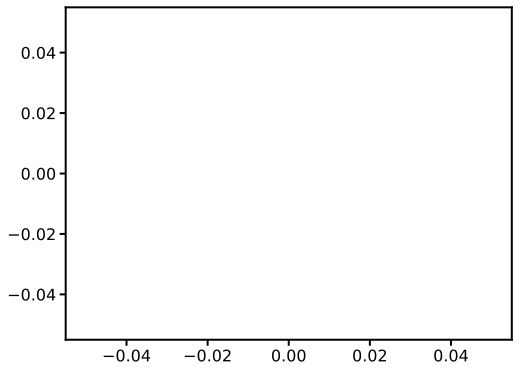

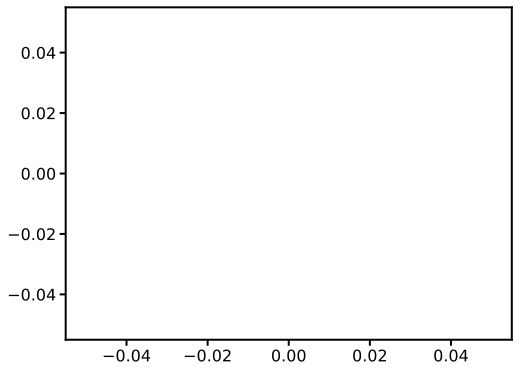

In [ ]:
freq, amp_u, pha_u = get_fftw(Iload[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Iload_fft_amp')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Iload_fft_pha')

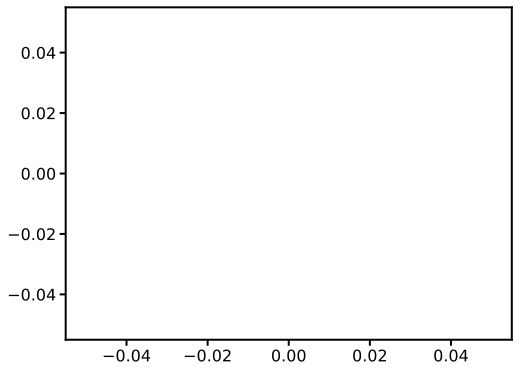

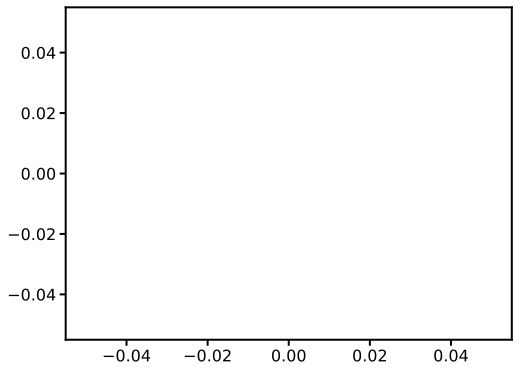

In [ ]:
freq, amp_u, pha_u = get_fftw(Vccp[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Uccp_fft_amp')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Uccp_fft_pha')

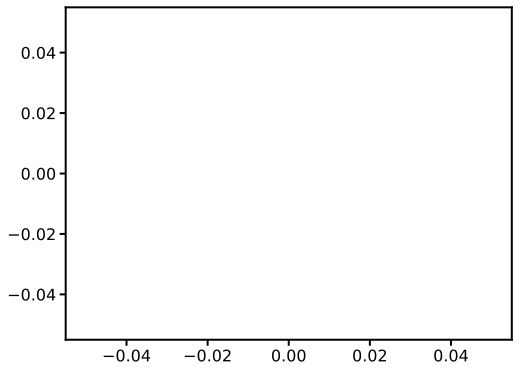

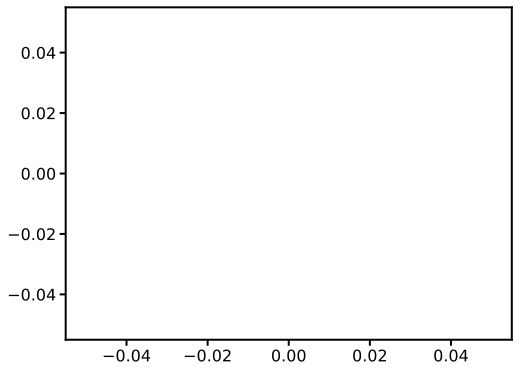

In [ ]:
freq, amp_u, pha_u = get_fftw(Iccp[istart:iend], dt, tol=0.001)
font, size = curvestyle()
plt.plot(freq[0:10000], amp_u[0:10000])
fs(name='./Iccp_fft_pha')

font, size = curvestyle()
plt.plot(freq[0:10000], pha_u[0:10000])
fs(name='./Iccp_fft_pha')

In [ ]:
power_all = get_base_power(Vs[istart:iend], Iload[istart:iend], dt, f)
power_load = get_base_power(Uload[istart:iend], Iload[istart:iend], dt, f)
power_stray = get_base_power(Vccp[istart:iend], Im2[istart:iend], dt, f)
power_ccp = get_base_power(Vccp[istart:iend], Iccp[istart:iend], dt, f)

In [ ]:
power_all, power_all - power_load, power_load - power_stray, power_stray - power_ccp, power_ccp

(0.0, 0.0, 0.0, 0.0, 0.0)